<a href="https://colab.research.google.com/github/davidmkidd/UK-Supermarket-Carbon-Emissions/blob/main/UKSmktComp_Emissions_Scope1and2_Location.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://evoviz.uk/wp-content/uploads/2026/04/Food_Divider_trans2.png">

# Scope 1 and 2 Location-based

Combined Scope 1 and 2 emissions measure the overall carbon emissions a retailer produces from its direct operations based on average source intensity, primarily the UK National Grid.

$C_{scope12, location} = C_{scope1} + C_{scope2, location}$

# Set-up


In [ ]:
# Load libraries
library(dplyr)   # Data manipulation
library(ggplot2) # Graphing
library(repr)    # Graph size
options(repr.plot.width = 10, repr.plot.height = 8)
library(broom)   # Format model output
library(knitr)    # Format model output

# Download cleaned and summarised emmissions data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_emissions_yr.csv"
download_path <- "/content/retailer_emissions_yr.csv"
download.file(url, destfile = download_path, mode = "wb")
emissions.yr <- read.csv("/content/retailer_emissions_yr.csv", header=TRUE, stringsAsFactors=FALSE)

# Download retailer data
url <- "https://raw.githubusercontent.com/davidmkidd/UK-Supermarket-Carbon-Emissions/refs/heads/main/retailer_data.csv"
download_path <- "/content/retailer_data.csv"
download.file(url, destfile = download_path, mode = "wb")
retailer.data <- read.csv("/content/retailer_data.csv", header=TRUE, stringsAsFactors=FALSE)

# Make palette list
retailer.pal <- setNames(retailer.data$hex, retailer.data$retailer_code)
# Make code/name list
retailer.code <- setNames(retailer.data$retailer, retailer.data$retailer_code)

# Truncate year to 1s and 10s
emissions.yr$year2 <- emissions.yr$year - 2000

# Split reported absolute and intenstity values into seperate data frames as they will will be used differenty.

# Reported Absolute Values
emissions.yr.absolute <- emissions.yr %>%
   filter(kpi_type == "Measure")
nrow(emissions.yr.absolute)

# Reported Intensity Values
emissions.yr.intensity <- emissions.yr %>%
   filter(kpi_type == "Intensity")
nrow(emissions.yr.intensity)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] 592

[1] 181

# Absolute Emissions

In [ ]:
# Location-based Scope 1 and 2
data.abs <- emissions.yr.absolute %>%
  filter(kpi == "Scope 1 and 2" & method == "Location")
nrow(data.abs)

[1] 106

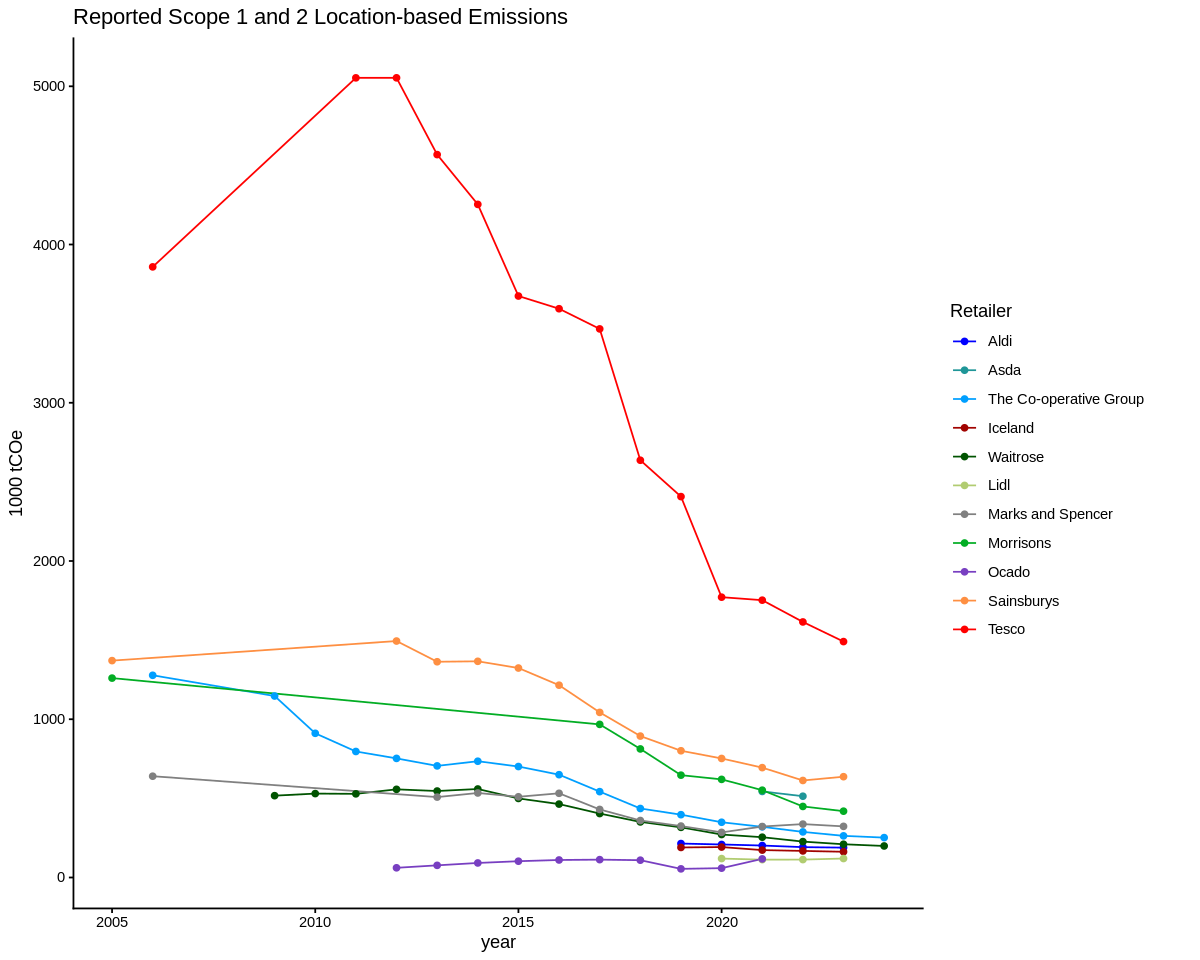

In [ ]:
# Plot absolute values
ggplot(data.abs, aes(x = year, y = value/1000, colour = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  geom_point(na.rm = TRUE) +
  ggtitle("Reported Scope 1 and 2 Location-based Emissions") +
  ylab("1000 tCOe") +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  theme_classic()

* Most retailers show a reduction in combined Sope 1 and 2 emissions.
* Tesco has much greater Scope 1 and 2 emissions that other retailers but also shows huge reductions.
* Ocado and M&S show marginal increases. Ocado is growing and M&S have a reporting correction.
* Tesco has the greatest Scope 1 and 2 emissions.

Scope 1 and 2 location-based emissions are the sum of two metrics that both are strongly linearly with total store area, so are expected to also be linear.

In [ ]:
# Calculate mean emissions for years 2020 for regression models
data.abs.mean <- data.abs %>%
  filter(year >= 2020 & year <= 2022) %>%
  group_by(retailer_code) %>%
  summarise_at(vars(value, total_store, total_area),list(mean = mean))

## Store Number

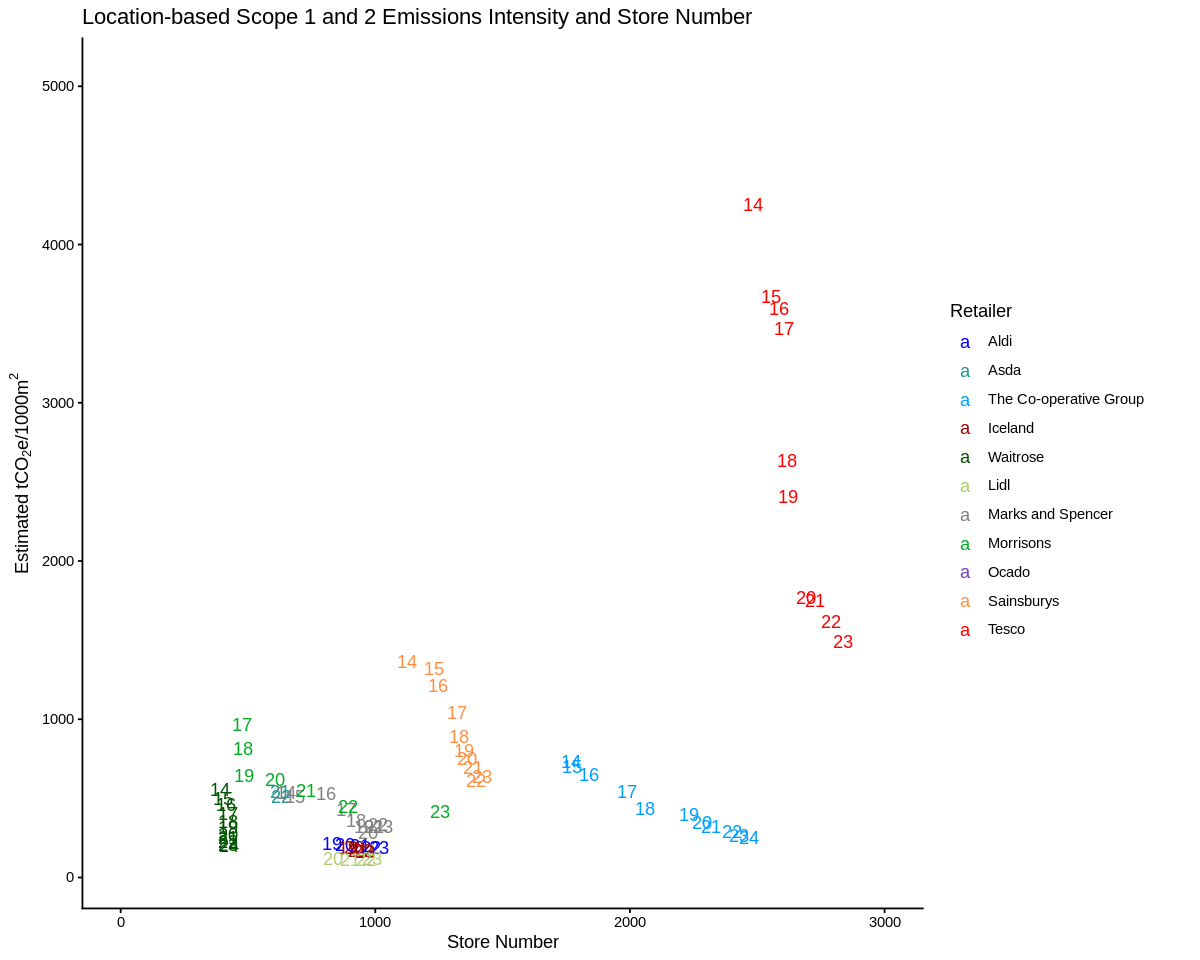

In [ ]:
ggplot(data.abs, aes(x = total_store, y = value/1000, colour = retailer_code, labels = year2)) +
  geom_text(na.rm = TRUE) +
  ggtitle("Location-based Scope 1 and 2 Emissions Intensity and Store Number") +
  xlab("Store Number") +
  ylab(expression(paste("Estimated tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0, 3000)) +
  theme_classic()

[1] "Store Number"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|     0.468|         0.401| 362591.3|     7.034|   0.029|  1| -141.084| 288.168| 289.076| 1.051779e+12|           8|   10|



|term             |   estimate|  std.error| statistic| p.value|
|:----------------|----------:|----------:|---------:|-------:|
|(Intercept)      | -26721.223| 224315.516|    -0.119|   0.908|
|total_store_mean |    426.096|    160.654|     2.652|   0.029|

[1] ""

`geom_smooth()` using formula = 'y ~ x'


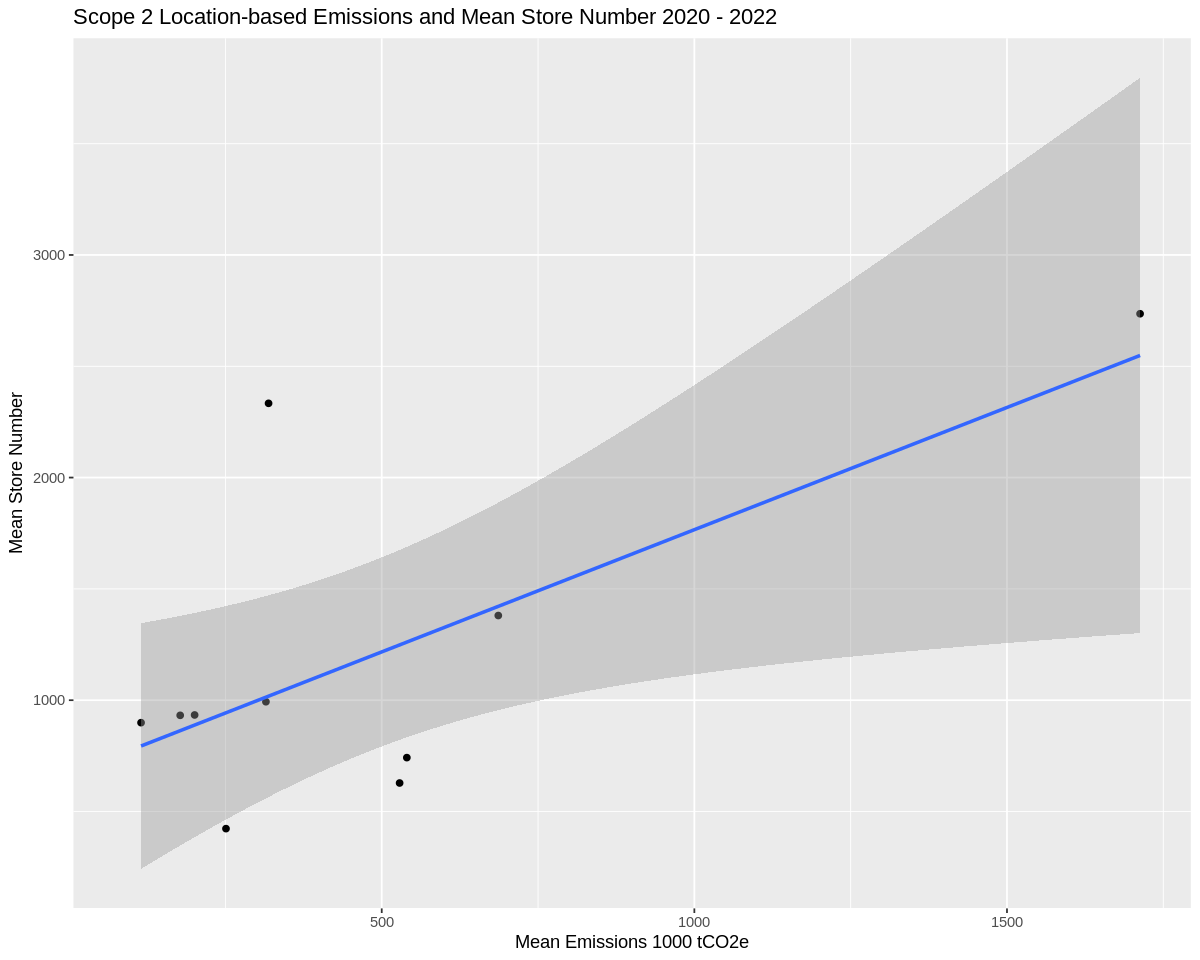

In [ ]:
# Scope 2 location ~ Store Number
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean, na.action=na.omit)
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

ggplot(data.abs.mean, aes(x = value_mean/1000, y = total_store_mean)) +
  geom_point(na.rm = TRUE) +
  geom_smooth(method='lm', na.rm = TRUE) +
  ggtitle("Scope 2 Location-based Emissions and Mean Store Number 2020 - 2022") +
  xlab("Emissions 1000 tCO2e") +
  ylab("Store Number")

## Store Area

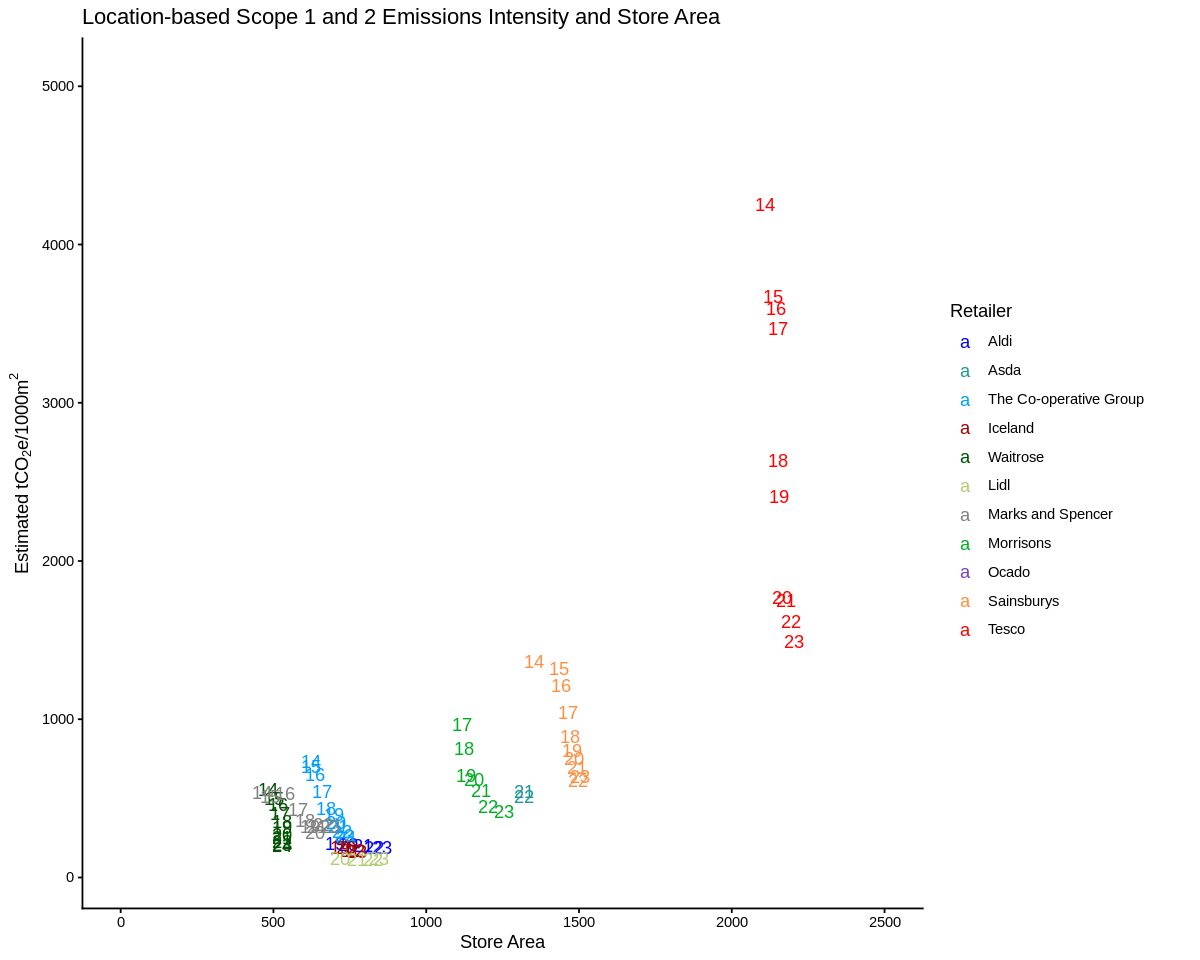

In [ ]:
  ggplot(data.abs, aes(x = total_area/1000, y = value/1000, colour = retailer_code, labels = year2)) +
  #geom_line(na.rm = TRUE)  +
  geom_text(na.rm = TRUE) +
  ggtitle("Location-based Scope 1 and 2 Emissions Intensity and Store Area") +
  xlab("Store Area") +
  ylab(expression(paste("Estimated tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(0, 2500)) +
  theme_classic()

* Scope 1 and 2 emissions appears to be more linear with store area than number.

[1] "Store Area"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|    deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|-----------:|-----------:|----:|
|     0.873|         0.857| 177202.2|    54.948|       0|  1| -133.924| 273.848| 274.756| 2.51205e+11|           8|   10|



|term            |    estimate|  std.error| statistic| p.value|
|:---------------|-----------:|----------:|---------:|-------:|
|(Intercept)     | -405396.849| 132499.229|    -3.060|   0.016|
|total_area_mean |       0.859|      0.116|     7.413|   0.000|

[1] ""

`geom_smooth()` using formula = 'y ~ x'


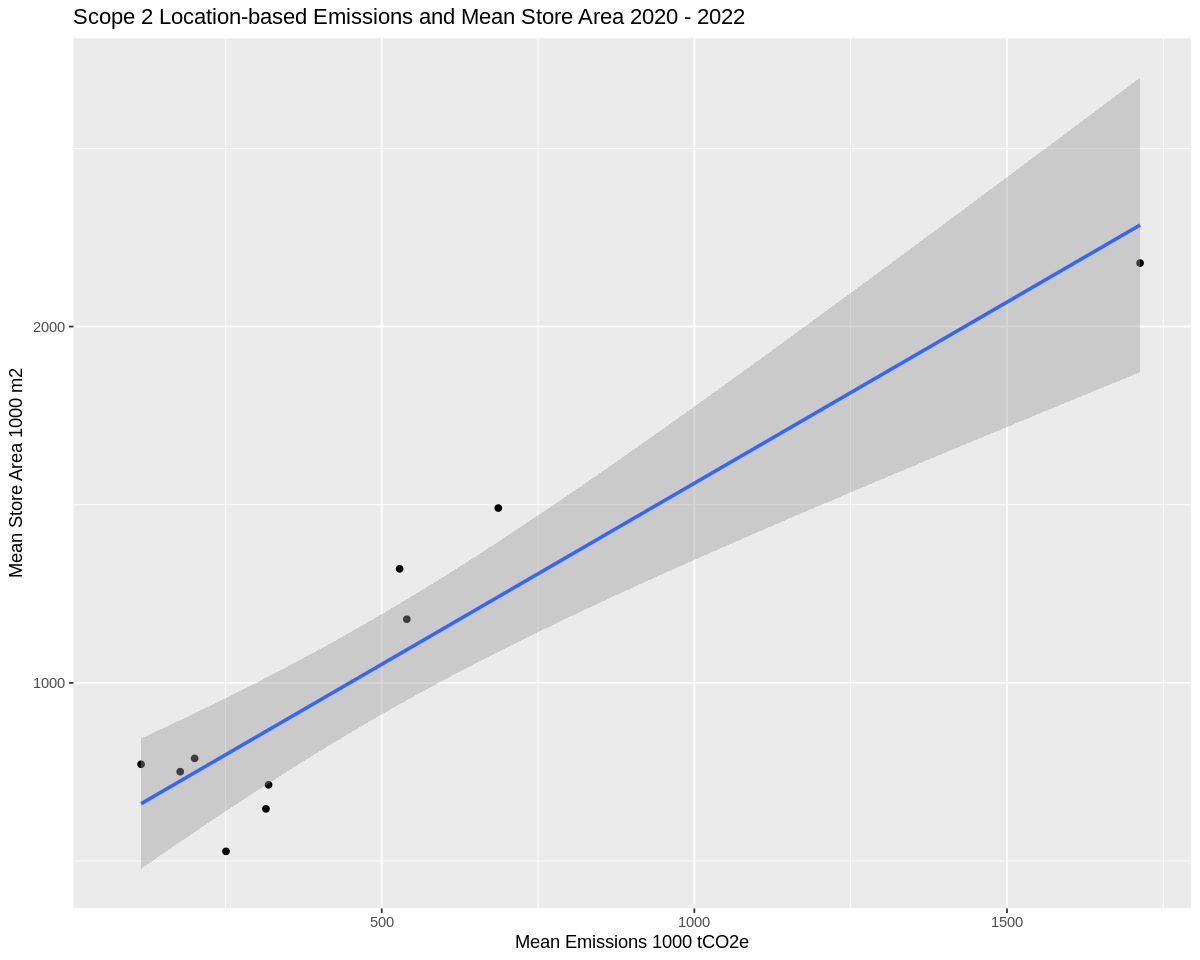

In [ ]:
# Scope 2 location ~ Store Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_area_mean, na.action=na.omit)
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

ggplot(data.abs.mean, aes(x = value_mean/1000, y = total_area_mean/1000)) +
  geom_point(na.rm = TRUE) +
  geom_smooth(method='lm', na.rm = TRUE) +
  ggtitle("Scope 2 Location-based Emissions and Mean Store Area 2020 - 2022") +
  xlab("Mean Emissions 1000 tCO2e") +
  ylab("Mean Store Area 1000 m2")

## Store Number and Area

In [ ]:
# Scope 2 location ~ Store Number + Area
lm_model <- lm(data = data.abs.mean, value_mean ~ total_store_mean + total_area_mean, na.action=na.omit)
glance(lm_model) %>%
  kable(digits = 3)
tidy(lm_model) %>%
  kable(digits = 3)
paste("")

[1] "Store Number +  Area"



| r.squared| adj.r.squared|    sigma| statistic| p.value| df|   logLik|     AIC|     BIC|     deviance| df.residual| nobs|
|---------:|-------------:|--------:|---------:|-------:|--:|--------:|-------:|-------:|------------:|-----------:|----:|
|      0.91|         0.884| 159682.6|    35.259|       0|  2| -132.215| 272.431| 273.641| 178489833154|           7|   10|



|term             |    estimate|  std.error| statistic| p.value|
|:----------------|-----------:|----------:|---------:|-------:|
|(Intercept)      | -454531.599| 122893.385|    -3.699|   0.008|
|total_store_mean |     144.492|     85.564|     1.689|   0.135|
|total_area_mean  |       0.739|      0.126|     5.852|   0.001|

[1] ""

## Best Model

* Store number predicts 46.8% (r.squared) of Scope 2 emissions with *p* = 0.029.

* Store area predicts 87.3% of Scope emissions with *p* = <0.001.

* Both variables explain the most variation (91%), but store number is not significant (p = 0.135).

The best model is:  $C{scope12, location} \sim StoreArea$

In [ ]:
# Calculate estimated intensity for absolute values
data.abs$intensity <- data.abs$value/data.abs$total_area

# Emission Intensity

In [ ]:
# Reported Intensity?
data.int <- emissions.yr.intensity %>%
  filter(kpi == "Scope 1 and 2" & method == "Location" & unit_denom_1 == "m2")
nrow(data.int)

[1] 45

There are reported Scope 1 and 2 intensity metrics!

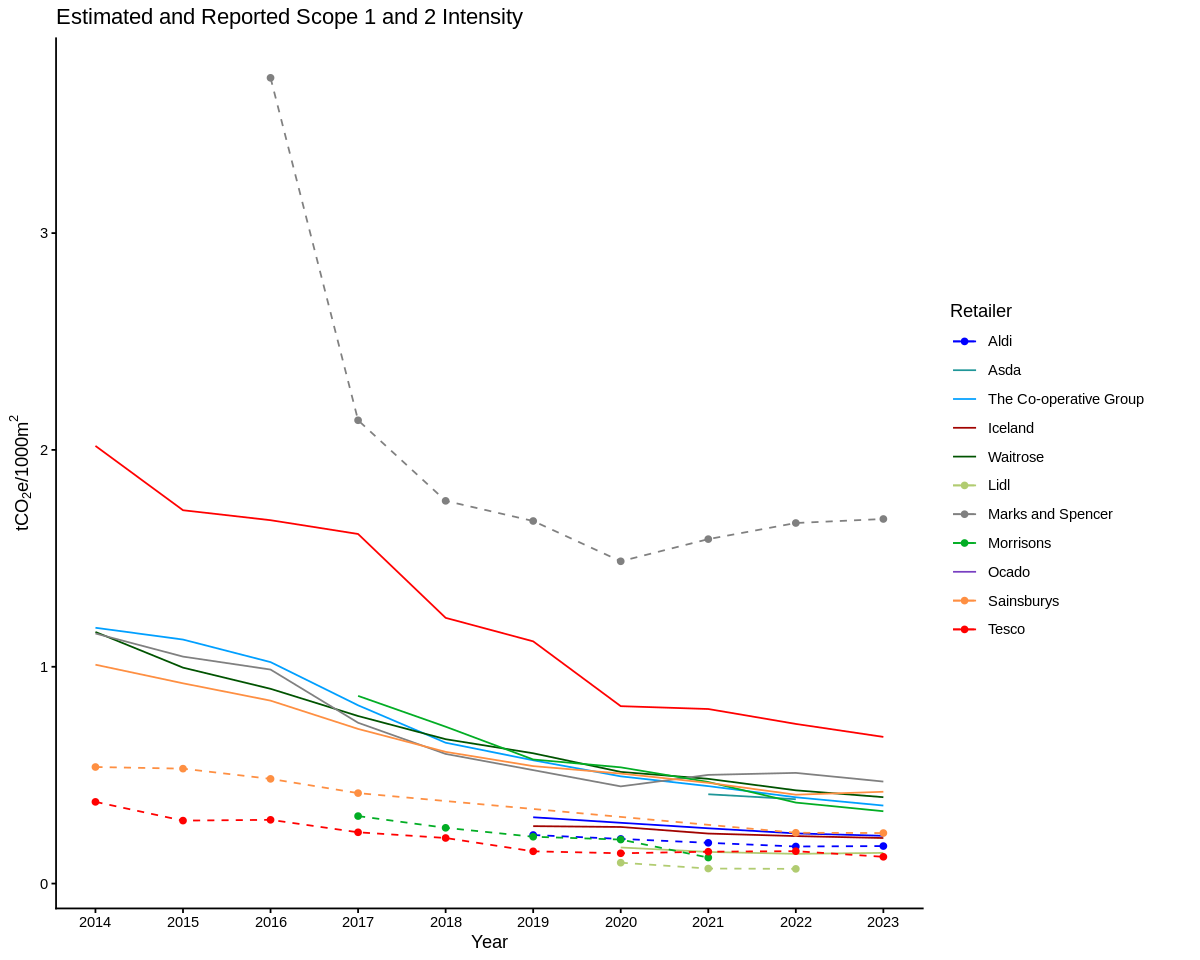

In [ ]:
ggplot(data.abs, aes(x = year, y = intensity, colour = retailer_code)) +
  geom_line(na.rm = TRUE)  +
  #geom_point(na.rm = TRUE) +
  geom_line(data = data.int, aes(x = year, y = value), na.rm = TRUE, linetype="dashed")  +
  geom_point(data = data.int, aes(x = year, y = value), na.rm = TRUE) +
  ggtitle("Estimated and Reported Scope 1 and 2 Intensity") +
  xlab("Year") +
  ylab(expression(paste("tCO"[2],"e/1000m"^2))) +
  scale_colour_manual(name = "Retailer", values = retailer.pal, labels = retailer.code) +
  scale_x_continuous(limits = c(2014, 2023), breaks=seq(2014,2023)) +
  theme_classic()

* Scope 1 and 2 combined emission intensity of most retailers has declined.
* Tesco has the highest estimated intensity noticably greater than other retailers.
* Aldi and Iceland have lower intensity than other retailers that bunch closely together.
* Reported intensties are lower than estimated for all retailers except, M&S which also reports considerably higher intensities than other retailers.

The relationship between estimated and reported intensity is further evaluated in [Workbook 10 Intensity Metric Model Fit](https://colab.research.google.com/drive/1uMGFcN7pux7t5DKm_GV6ee2LSVsGIBVf?usp=sharing).

---

[Main Page](https://colab.research.google.com/drive/1f8a0pXfF9PqCujiwjf4TO4-k7ezt-6b3?usp=sharing)

[Scope 1 and 2 Market-based](https://colab.research.google.com/drive/1MvdMFH9blIjT7dHAddXlgNIksMtOk8IW?usp=sharing)

---
